# Data Visualization Ethics Challenge

In this activity, you’ll work with a simple dataset and examine two deliberately bad charts.  
Each one ignores multiple best practices for ethical and effective visualization.

Your job is to:

1. Review each chart and note at least three issues you see.  
2. Create a new chart (or charts) that present the data clearly, accurately, and honestly.  
3. Include clear labels, a cited data source, and a descriptive but neutral title.

**Remember:** Strong visualizations tell the truth, provide context, and avoid design choices that distort or mislead.


## Step 1: Load the dataset

We’re using a provided CSV file with fictional sales data for a coffee chain.  
No need to modify anything in this cell — just run it so the dataset loads into your notebook.  
Once loaded, take a quick look at the first few rows to get familiar with the columns and values.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

coffee_df = pd.read_csv("fake_coffee_chain_sales.csv")
coffee_df.head()

,Year,Month,Region,Category,Sales,Profit
0,2020,January,East,Espresso,14724,5290.46
1,2020,January,East,Lattes,11948,4138.77
2,2020,January,East,Tea,18660,5959.44
3,2020,January,East,Pastries,11265,2604.46
4,2020,January,East,Beans,8954,2613.22


## Step 2: Review the BAD Charts

Below are two deliberately poor visualizations.  
Your task: Carefully review each and take notes on what you think is wrong, misleading, or just poorly designed.  
Think about chart type, colors, scales, labeling, and whether the chart tells the truth.  


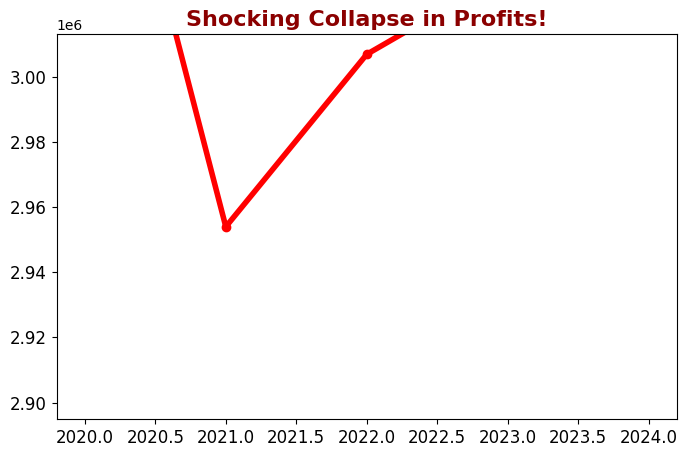

In [2]:
plt.figure(figsize=(8,5))
subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()

# Wrong variable for title, truncated y-axis, misleading color & framing
plt.plot(subset["Year"], subset["Sales"], color="red", linewidth=4, marker="o")
plt.ylim(subset["Sales"].min() * 0.98, subset["Sales"].min() * 1.02)  # extreme truncation
plt.title("Shocking Collapse in Profits!", fontsize=16, fontweight="bold", color="darkred")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


### Write your notes about bad chart #1 here:
- No axis labels. One assumes that x-axis is year, but one should not be required to assume.
- What even is *1e6* at the top left?
- Only two data points are technically visible: 2021.0 at around 2.95 and 2022 at around 3.05.
- The title is "aggressive", and you can't even tell if it's accurate without seeing more of the chart.
- It's plotting sales, but the title says "Profits". Quite notably, these are not the same thing.

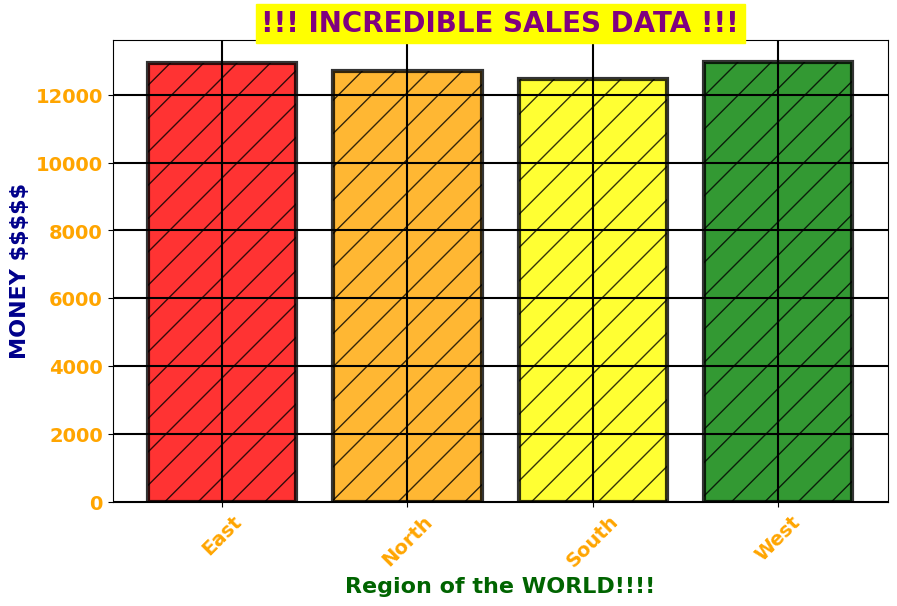

In [3]:
plt.figure(figsize=(10,6))
avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()

colors = ["red","orange","yellow","green","blue","purple"]

plt.bar(avg_sales["Region"], avg_sales["Sales"], 
        color=colors, edgecolor="black", linewidth=3, hatch="/", alpha=0.8)
plt.title("!!! INCREDIBLE SALES DATA !!!", fontsize=20, fontweight="bold", color="purple", backgroundcolor="yellow")
plt.grid(True, which='both', color='black', linestyle='-', linewidth=1.5)
plt.xlabel("Region of the WORLD!!!!", fontsize=16, fontweight="bold", color="darkgreen")
plt.ylabel("MONEY $$$$$", fontsize=16, fontweight="bold", color="darkblue")
plt.xticks(rotation=45, fontsize=14, fontweight="bold", color="orange")
plt.yticks(fontsize=14, fontweight="bold", color="orange")
plt.show()


### Write your notes about bad chart #2 here:
- So busy: the grid lines are not required. The diagonal hashing is not required. The colors are garish. 
- All caps on y-axis label and title. Also one word of x-axis label is all caps, for *reasons*, one supposes.
- There is a lot wrong with this chart, but it basically boils down to: It's difficult to look at.

## Step 3: Your Turn – Make It Right

Now it’s your turn to fix things.  

- Start by thinking about a question you want to answer with this dataset.  
- Choose a visualization type that matches your question and the data structure.  
- Apply the best practices from our lessons: clear labeling, appropriate scale, purposeful color, simplicity, and accessibility.  
- Be honest - don’t manipulate the chart to make a point that the data doesn’t support.  

When you’re done, add your chart(s) below. You may create more than one if it helps tell the story better.  


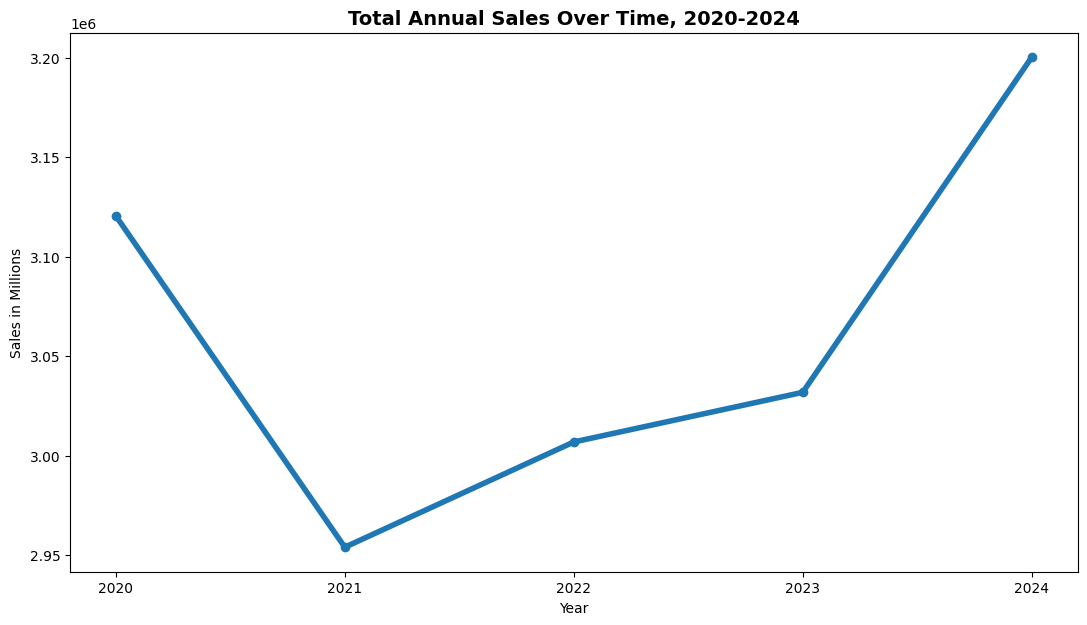

In [4]:
# Your GOOD visualization(s) here

# plot what possibly the original bad chart was meant to be: annual sales 2020-2024
plt.figure(figsize=(13,7))
annl_sales = coffee_df.groupby('Year')['Sales'].sum().reset_index()
plt.plot(annl_sales['Year'], annl_sales['Sales'], linewidth=4, marker="o")
plt.title("Total Annual Sales Over Time, 2020-2024", fontsize=14, fontweight="bold")
plt.xticks(ticks=annl_sales['Year'], labels=annl_sales['Year'], fontsize=10)
plt.xlabel('Year')
plt.ylabel('Sales in Millions')
plt.show()


In [5]:
# map months to numbers so we can see nuance over time
month_map = {
    "January": 1,
    "February": 2, 
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12
}

# make a Month_Name column because, for whatever reason, pd.to_datetime works with Month but not with, say, Month_Value. so we need Month for the date conversion.
coffee_df['Month_Name'] = coffee_df['Month']
# insert month numbers as a column
coffee_df['Month'] = coffee_df['Month_Name'].map(month_map)
# add day placeholder
coffee_df['Day'] = 1
# when viewing these three columns, and coffee_df.info(), these all read as int
full_date = coffee_df[['Year', 'Month', 'Day']]
# make a datetime column called 'Timeframe'
coffee_df['Timeframe'] = pd.to_datetime(full_date)

# group sales by Category and Month
cat_sales_by_month = coffee_df.groupby(['Timeframe', 'Category'])['Sales'].sum().reset_index()

# i have spent so much time on this. should have kept it simple.


Text(0, 0.5, 'Sales (US Dollars)')

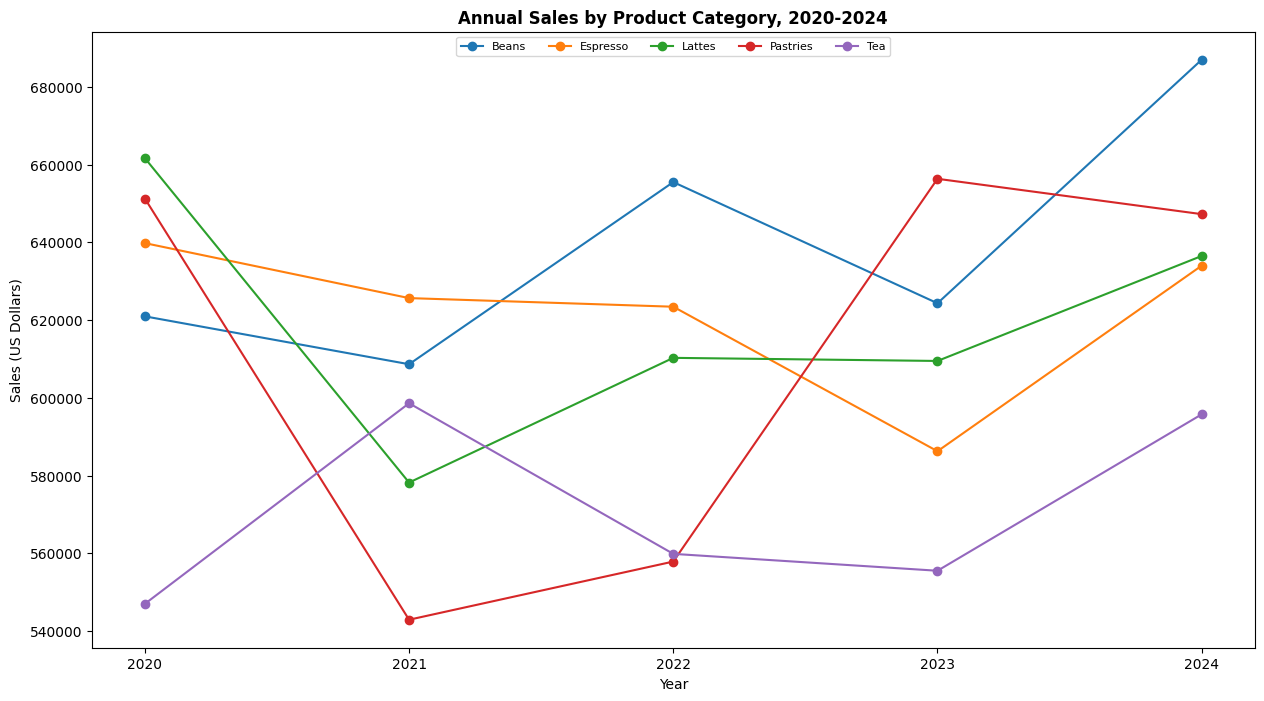

In [ ]:
# break out sales by Category instead of total annual sales

# group total Sales data by Year and Category
category_sales_annual_grouped = coffee_df.groupby(['Year', 'Category'])['Sales'].sum().reset_index()
# turn the new grouped dataframe sideways to get Category as columns
category_sales_annual = category_sales_annual_grouped.pivot(index='Year', columns='Category', values='Sales')

# make essentially the same plot as above, but with five lines, one for each Category
fig = plt.figure(figsize=(15,8))
for col in category_sales_annual.columns:
    plt.plot(category_sales_annual.index, category_sales_annual[col], label=col, marker='o')
plt.legend(fontsize=8, loc='upper center', ncols=5) # small font for legend, top center has some free space
plt.title("Annual Sales by Product Category, 2020-2024", fontweight='bold')
plt.xticks(ticks=category_sales_annual.index, labels=['2020', '2021', '2022', '2023', '2024']) # clean up the appearance of the x-axis labels
plt.xlabel('Year')
plt.ylabel('Sales (US Dollars)')

In [7]:
coffee_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Year        1200 non-null   int64         
 1   Month       1200 non-null   int64         
 2   Region      1200 non-null   str           
 3   Category    1200 non-null   str           
 4   Sales       1200 non-null   int64         
 5   Profit      1200 non-null   float64       
 6   Month_Name  1200 non-null   str           
 7   Day         1200 non-null   int64         
 8   Timeframe   1200 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4), str(3)
memory usage: 84.5 KB


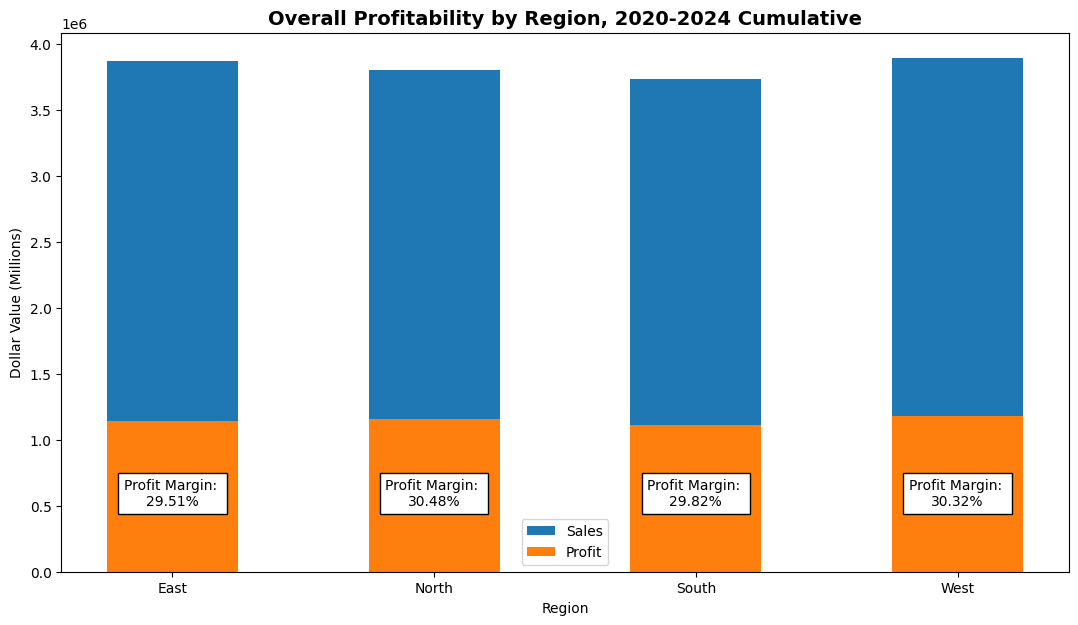

In [ ]:
# does profitability vary by region?

# sum up regional sales
regional_sales = coffee_df.groupby('Region')['Sales'].sum().reset_index()
# sum up regional profits
regional_profit = coffee_df.groupby('Region')['Profit'].sum().reset_index()
# merge sales and profits dataframes
regional_KPIs = regional_sales.merge(regional_profit, how='inner')
# add a profit margin column
regional_KPIs['Profit_Margin'] = (regional_KPIs['Profit'] / regional_KPIs['Sales'])*100
# limit profit margin percentage to 2 decimal places
regional_KPIs['Profit_Margin'] = regional_KPIs['Profit_Margin'].map('{:,.2f}%'.format)

# plot Sales and Profit on primary y-axis as bars; use Profit_Margin as a label
plt.figure(figsize=(13,7))
plt.bar(regional_KPIs.index, regional_KPIs['Sales'], width=0.5)
plt.bar(regional_KPIs.index, regional_KPIs['Profit'], width=0.5)
plt.title("Overall Profitability by Region, 2020-2024 Cumulative", fontsize=14, fontweight="bold")
plt.xticks(ticks=regional_KPIs.index, labels=regional_KPIs['Region'], fontsize=10)
plt.xlabel('Region')
plt.ylabel('Dollar Value (Millions)')
plt.legend(regional_KPIs[['Sales', 'Profit']], loc='best')
loop_counter = 0

for i in regional_KPIs.index:
    plt.text(loop_counter,500000,'Profit Margin: \n' + str(regional_KPIs['Profit_Margin'][loop_counter]), ha='center', bbox=dict(facecolor='white'))
    loop_counter += 1
plt.show()